# Comparaison de méthodes métaheuristiques sur une instance de grande taille

In [1]:
%load_ext autoreload
%autoreload 2


from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

import sys
sys.path.append('../src/')
sys.path.append('../tests/')
from tests import *
from time import time


from utils import *
from Instance import *
from Solution import *
from metaheuristic_approach import *


from copy import deepcopy
from time import time


##### MILP MODEL #####
import gurobipy as gp
from gurobipy import GRB

from first_model import *



# fonction de validation des chromosomes
from validator_metaheuristique import (
    validate_best_chromosomes,
    print_validation_summary,
)

#fonction de validation des solutions MILP
from validator_model import (
    solve_and_validate_model,
    validate_model_solutions,
    print_validation_summary,
    validate_model_solution,
)



In [2]:
TIME_DAY = 42 # 42 unités de temps = 1 journée de travail soit 7h

In [3]:
time_type_of_jobs = {
    "small": (3, 9),
    "medium": (9, 18),
    "long": (18, 42)
}

Seed aléatoire pour l'instance : 9795
set
[{128, 3, 133, 136, 144, 145, 147, 22, 152, 27, 32, 34, 36, 42, 44, 46, 50, 52, 53, 62, 67, 70, 73, 75, 84, 85, 87, 89, 90, 95, 96, 97, 99, 115, 119, 126}, {0, 2, 130, 4, 131, 6, 134, 10, 12, 13, 140, 141, 142, 17, 18, 143, 20, 146, 23, 24, 25, 29, 30, 35, 39, 47, 51, 57, 58, 65, 66, 68, 71, 74, 77, 79, 81, 82, 88, 92, 93, 94, 98, 101, 102, 103, 107, 108, 110, 112, 118, 121, 122, 123, 124, 125}, {1, 129, 132, 5, 7, 8, 9, 135, 11, 137, 138, 14, 15, 16, 139, 19, 148, 21, 149, 150, 151, 153, 26, 28, 31, 33, 37, 38, 40, 41, 43, 45, 48, 49, 54, 55, 56, 59, 60, 61, 63, 64, 69, 72, 76, 78, 80, 83, 86, 91, 100, 104, 105, 106, 109, 111, 113, 114, 116, 117, 120, 127}]
ColorLegend= {'job with qualified workers': 'green', 'job without qualified workers': 'red', 'job have at most one level of difference': 'orange'}


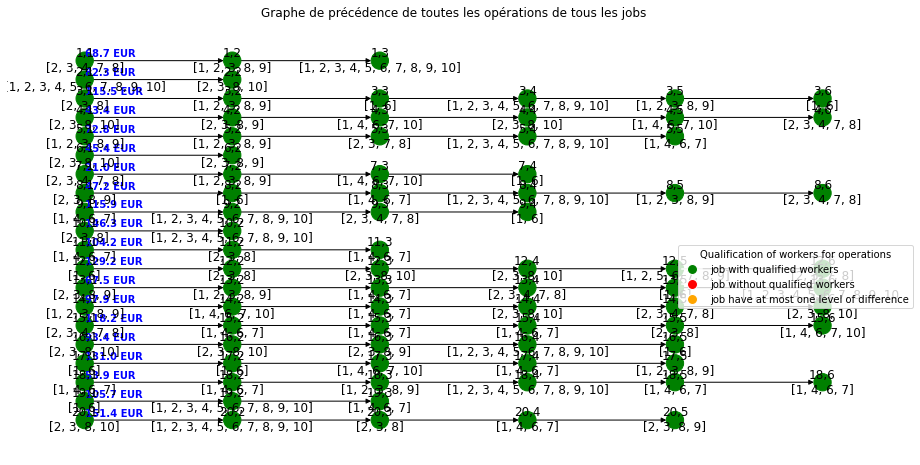

In [4]:
seed = np.random.randint(0, 10000)
print(f"Seed aléatoire pour l'instance : {seed}")
config_instance = {
    "seed": seed,
    "nb_jobs": 20,
    "nb_workers": 10,
    "nb_professions": 5,
    "proportion_tasks_per_profession": [0.2, 0.2, 0.2, 0.2, 0.2], # [profession 1, profession 2, profession 3, profession 4, profession 5]
    "max_nb_operations": 7,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.1, 0.4, 0.4], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.3, 0.3, 0.1, 0.1], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": True
}

instance = Instance()
instance.from_config(config_instance)

visualization_before_scheduling(instance, not_qualified=True)

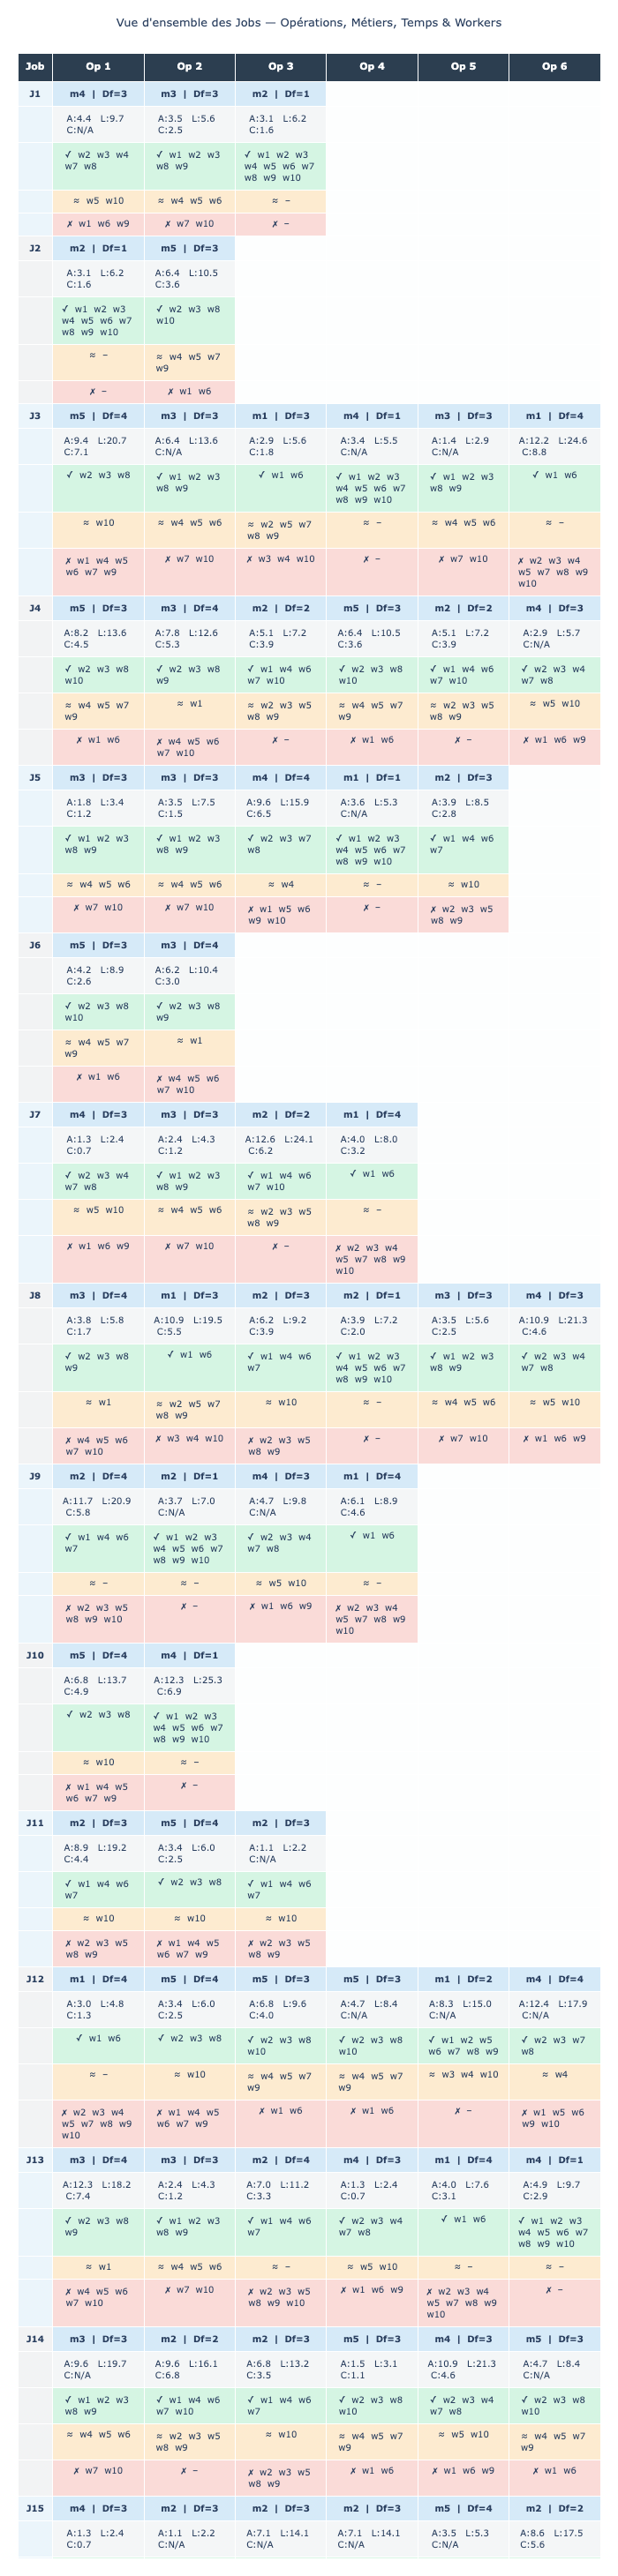

In [5]:
instance.visualize_jobs_overview(render="notebook")

In [7]:
print(" sum of jobs alone: ", instance.sum_of_job_alone())
print(" mean time of jobs alone: ", instance.mean_time_job_alone())
print(" mean time of operations: ", instance.mean_time_operations())
print(" time of each job alone: ", instance.time_each_job_alone())
print(" sum of profit of jobs: ", instance.sum_profit_of_jobs())

 sum of jobs alone:  527.7150854055795
 mean time of jobs alone:  26.385754270278976
 mean time of operations:  4.55
 time of each job alone:  [10.99698138152766, 9.48184926342522, 35.71254588111734, 35.45110781802244, 22.344083981865527, 10.397383724923188, 20.261003196988373, 39.13612008989219, 26.13176614432343, 19.124287651527123, 13.394028240388405, 38.48980311035279, 31.77012976128355, 43.04042160685209, 28.8200106382122, 34.53099306849747, 38.9993311011993, 31.840432749219993, 13.975758303081212, 23.817047692880152]
 sum of profit of jobs:  1810.9978148746663


In [8]:
constraints_config = {"job_with_no_skills": False,
                        "constrained_makespan": 50,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                 }

In [9]:
weights = {
    "profit" : 100,
    "skills" : 10,
    "cognitive_load" : 1
    }

In [10]:
ONE_NB_SEED = 5
MAX_EVAL = 5000

enc   = Encoding_Dicos(instance)
gen   = ChromosomeGenerator(instance, enc, constraints_config=constraints_config)
dec   = Decoder(instance, enc, constraints_config=constraints_config)
eval  = Evaluator(dec, weights)
sel   = BestSelector()


# RANDOM SEARCH

In [11]:
rs_times = np.zeros(ONE_NB_SEED)
rs_all_viewed = []
rs_best_list = []
rs_index_best_list = []

In [12]:
for nb_seed in range(ONE_NB_SEED):

    rs = RandomSearch(gen, eval)
    t = time.time()

    av, bl, indx_bests, best_c = rs.run(MAX_EVAL, verbose=False)
    
    rs_times[nb_seed] = time.time() - t
    rs_all_viewed.append(av)
    rs_best_list.append(bl)
    rs_index_best_list.append(indx_bests)

Random Search Iterations: 100%|██████████| 5000/5000 [00:36<00:00, 137.41it/s]


In [13]:
for i in range(ONE_NB_SEED):
    print(f"Seed {i+1}:")
    print(rs_best_list[i][-1].fitness)
    print(rs_best_list[i][-1].objectives)
    print(f"Time taken: {rs_times[i]:.2f} seconds\n")

Seed 1:
78923.85347405968
(790.9008714779544, 4.0, -206.2336737357527)
Time taken: 42.99 seconds

Seed 2:
77335.1025199886
(775.56882595242, 2.0, -241.78007525338762)
Time taken: 44.19 seconds

Seed 3:
76413.81745809787
(765.5996674146717, 3.2492542656174237, -178.64182602547672)
Time taken: 35.88 seconds

Seed 4:
76879.83507991495
(770.5996674146717, 2.614706736162617, -206.27872891384624)
Time taken: 36.27 seconds

Seed 5:
81795.79768937237
(819.5122750063049, 4.0, -195.42981125811198)
Time taken: 36.39 seconds



In [14]:
rs_index_best_list

[[0, 17, 28, 78, 736, 1736, 3326],
 [0, 2, 15, 19, 53, 338, 836, 878],
 [0, 15, 17, 98],
 [0, 4, 24, 40, 56, 67, 112, 362, 548, 720, 1654],
 [0, 1, 2, 4, 21, 26, 91, 460, 1002]]

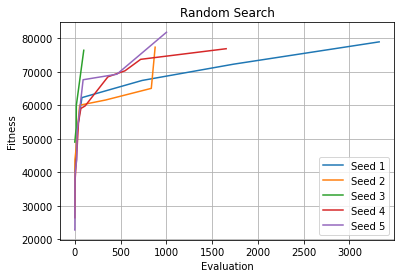

In [15]:
rs_best_list_fitness = [ [c.fitness for c in rs_best_list[i]] for i in range(ONE_NB_SEED) ]


for i in range(ONE_NB_SEED):
    plt.plot(rs_index_best_list[i], rs_best_list_fitness[i], label=f"Seed {i+1}")
    plt.grid()
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"Random Search")
    plt.legend()
plt.show()

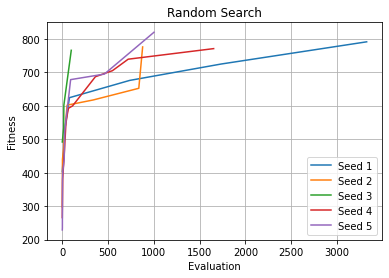

In [16]:
rs_best_list_objectif_economic = [ [c.objectives[0] for c in rs_best_list[i]] for i in range(ONE_NB_SEED) ]
for i in range(ONE_NB_SEED):
    plt.plot(rs_index_best_list[i], rs_best_list_objectif_economic[i], label=f"Seed {i+1}")
    plt.grid()
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"Random Search")
    plt.legend()
plt.show()

In [25]:
results_rs = np.zeros(ONE_NB_SEED)
for i in range(ONE_NB_SEED):
    results_rs[i] = rs_best_list[i][-1].fitness
print("Random Search Results:")
print(results_rs)
print("Mean:", np.mean(results_rs), "\nStd:", np.std(results_rs), "\nBest:", np.max(results_rs), "\nWorst:", np.min(results_rs))

Random Search Results:
[78923.85347406 77335.10251999 76413.8174581  76879.83507991
 81795.79768937]
Mean: 78269.6812442867 
Std: 1955.0334337768456 
Best: 81795.79768937237 
Worst: 76413.81745809787


# MLS

In [32]:
mls_times = np.zeros(ONE_NB_SEED)
mls_all_viewed = []
mls_best_list = []
mls_index_best_list = []
mls_best_c = []


for nb_seed in range(ONE_NB_SEED):
    print(f"MLS - Seed {nb_seed+1}/{ONE_NB_SEED}")

    mls = MultipleLocalSearch(gen, 
                              eval, 
                              ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gen), 
                              sel
    )
    t = time.time()

    av, bl, indx_bests, best_c = mls.run(MAX_EVAL, patience=100,verbose=False)
    
    mls_times[nb_seed] = time.time() - t
    mls_all_viewed.append(av)
    mls_best_list.append(bl)
    mls_index_best_list.append(indx_bests)
    mls_best_c.append(best_c)
    print("best fitness:", best_c.fitness, "best objectives:", best_c.objectives)

MLS - Seed 1/5
best fitness: 82504.16218798688 best objectives: (827.0835365165136, 4.0, -244.19146366447927)
MLS - Seed 2/5
best fitness: 71439.80854864346 best objectives: (716.3635652358403, 4.0, -236.54797494057038)
MLS - Seed 3/5
best fitness: 77262.00527126793 best objectives: (774.3530703981786, 4.0, -213.30176854991936)
MLS - Seed 4/5
best fitness: 75898.6068945866 best objectives: (760.7083782318704, 2.614706736162617, -198.37799596205397)
MLS - Seed 5/5
best fitness: 68438.04493700595 best objectives: (685.803884854495, 4.0, -182.34354844354996)


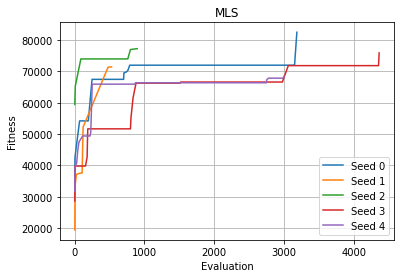

In [33]:
mls_best_list_objectif = [ [c.fitness for c in mls_best_list[i]] for i in range(ONE_NB_SEED) ]

for i in range(ONE_NB_SEED):
    y = np.array(mls_best_list_objectif[i])
    y = np.maximum.accumulate(y)
    plt.plot(mls_index_best_list[i], y, label=f"Seed {i}")
    plt.grid()
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"MLS")
    plt.legend()
plt.show()

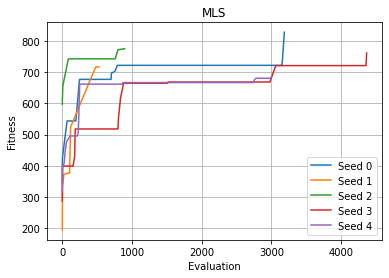

In [34]:
mls_best_list_objectif_economique = [ [c.objectives[0] for c in mls_best_list[i]] for i in range(ONE_NB_SEED) ]

for i in range(ONE_NB_SEED):
    y = np.array(mls_best_list_objectif_economique[i])
    y = np.maximum.accumulate(y)
    plt.plot(mls_index_best_list[i], y, label=f"Seed {i}")
    plt.grid()
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"MLS")
    plt.legend()
plt.show()

In [35]:
results_mls = np.zeros(ONE_NB_SEED)
for i in range(ONE_NB_SEED):
    results_mls[i] = mls_best_list[i][-1].fitness
print("Multiple Local Search Results:")
print(results_mls)
print("Mean:", np.mean(results_mls), "\nStd:", np.std(results_mls), "\nBest:", np.max(results_mls), "\nWorst:", np.min(results_mls))

Multiple Local Search Results:
[82504.16218799 71439.80854864 77262.00527127 75898.60689459
 68438.04493701]
Mean: 75108.52556789816 
Std: 4856.1701116514 
Best: 82504.16218798688 
Worst: 68438.04493700595


# VNS

In [ ]:
def build_neighborhoods(gen, nb_job_no_skills=0):
    """Retourne la liste des voisinages à tester — modifier ici pour ajouter/retirer un voisinage."""
    return [
        (SwapOperationNeighborhood(n=10, nb_job_no_skills=nb_job_no_skills), "Swap OSC"),
        (MoveOneOperationNeighborhood(),                                      "Move OSC"),
        (MoveSecondWorkerNeighborhood(gen),                                   "Move SWAC"),
        (MoveJobNeighborhood(n=3), "Move Job"),  # k=1 perturbation moyenne
        (ChangebaseWorkerNeighborhood(nb_job_no_skills=nb_job_no_skills, generator=gen), "Change Base Worker"),
        (ShuffleOperationsNeighborhood(n=10, nb_job_no_skills=nb_job_no_skills), "Shuffle OSC"),
        (multipleNeighborhood_alternating(
            SwapOperationNeighborhood(n=10, nb_job_no_skills=nb_job_no_skills),
            ChangebaseWorkerNeighborhood(nb_job_no_skills=nb_job_no_skills, generator=gen),
            nb_job_no_skills=nb_job_no_skills,
        ), "Alternating"),
        (RandomRestartNeighborhood(gen, n=1, nb_job_no_skills=nb_job_no_skills), "Random Restart"),
        
    ]
neighborhoods = build_neighborhoods(gen, nb_job_no_skills=0)

In [ ]:
vns_times = np.zeros(ONE_NB_SEED)
vns_all_viewed = []
vns_best_list = []
vns_index_best_list = []
vns_best_c = []

for nb_seed in range(ONE_NB_SEED):
    print(f"VNS - Seed {nb_seed+1}/{ONE_NB_SEED}")

    vns = VNS(gen, eval, neighborhoods, sel, ls_patience=100)
    t = time.time()

    av, bl, indx_bests, best_c = vns.run(MAX_EVAL, verbose=False)
    
    vns_times[nb_seed] = time.time() - t
    vns_all_viewed.append(av)
    vns_best_list.append(bl)
    vns_index_best_list.append(indx_bests)
    vns_best_c.append(best_c)


VNS - Seed 1/5
Swap OSC - Move OSC - Move SWAC - Move Job - Change Base Worker - Shuffle OSC - Alternating - Random Restart - 
Neighborhood current =  Swap OSC
Amélioration | fitness=66182.9672 | evals=142/5000 k= 0
Amélioration | fitness=74632.5424 | evals=327/5000 k= 0
Amélioration | fitness=75481.7680 | evals=438/5000 k= 0
Amélioration | fitness=82636.3036 | evals=1023/5000 k= 0
Re - Run avec candidat moins performant
Amélioration | fitness=61640.1335 | evals=2748/5000 k= 0
Amélioration | fitness=76017.5867 | evals=2928/5000 k= 0
Re - Run avec candidat moins performant
Amélioration | fitness=53657.1479 | evals=4051/5000 k= 0
Amélioration | fitness=58496.4032 | evals=4179/5000 k= 0
Amélioration | fitness=65630.8750 | evals=4439/5000 k= 0
VNS - Seed 2/5
Swap OSC - Move OSC - Move SWAC - Move Job - Change Base Worker - Shuffle OSC - Alternating - Random Restart - 
Neighborhood current =  Swap OSC
Amélioration | fitness=73023.2667 | evals=238/5000 k= 0
Re - Run avec candidat moins perfo

In [99]:
for i in range(ONE_NB_SEED):
    print(f"Seed {i+1}:")
    print(vns_best_c[i].fitness)
    print(vns_best_c[i].objectives)
    # print(vns_best_c[i])
    print(f"Time taken: {vns_times[i]:.2f} seconds")
    print("-----")

Seed 1:
55064.56994552992
(552.2754472096874, 4.114706736162617, -204.1218428004486)
Time taken: 17.31 seconds
-----
Seed 2:
49207.72941572346
(493.5815911336815, 7.0, -220.42969764469174)
Time taken: 16.35 seconds
-----
Seed 3:
48496.264001192336
(486.16117823115553, 7.114706736162617, -191.0008892848407)
Time taken: 17.07 seconds
-----
Seed 4:
63608.866322222355
(637.9008571972329, 3.5, -216.21939750093688)
Time taken: 15.44 seconds
-----
Seed 5:
68694.16316380822
(688.2873784638023, 7.5, -209.5746825720119)
Time taken: 16.61 seconds
-----


In [96]:
results_vns = np.zeros(ONE_NB_SEED)
for i in range(ONE_NB_SEED):
    results_vns[i] = vns_best_c[i].fitness
print("Variable Neighborhood Search Results:")
print(results_vns)
print("Mean:", np.mean(results_vns), "\nStd:", np.std(results_vns), "\nBest:", np.max(results_vns), "\nWorst:", np.min(results_vns))

Variable Neighborhood Search Results:
[55064.56994553 49207.72941572 48496.26400119 63608.86632222
 68694.16316381]
Mean: 57014.318569695264 
Std: 7965.029031351088 
Best: 68694.16316380822 
Worst: 48496.264001192336


# COMPARAISON DES RÉSULTATS

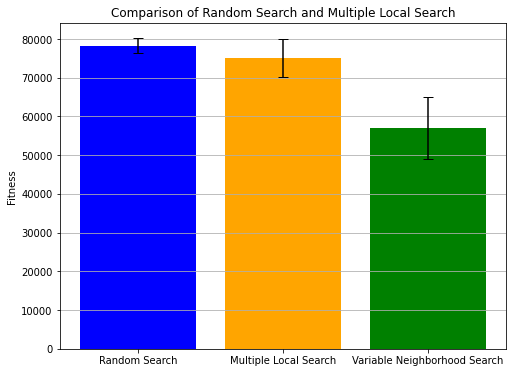

In [97]:
# comparaison des résultats entre Random Search et Multiple Local Search
mean_rs = np.mean(results_rs)
std_rs = np.std(results_rs)

mean_mls = np.mean(results_mls)
std_mls = np.std(results_mls)

mean_vns = np.mean(results_vns)
std_vns = np.std(results_vns)

plt.figure(figsize=(8, 6))
plt.bar(['Random Search', 'Multiple Local Search', "Variable Neighborhood Search"], [mean_rs, mean_mls, mean_vns], yerr=[std_rs, std_mls, std_vns], capsize=5, color=['blue', 'orange', 'green'])
plt.ylabel('Fitness')
plt.title('Comparison of Random Search and Multiple Local Search')
plt.grid(axis='y')
plt.show()


# Comparaions MLS voisinage

In [49]:
def run_mls(neighborhood, name, nb_seeds=ONE_NB_SEED, max_eval=MAX_EVAL, patience=100):
    """Lance MLS nb_seeds fois avec le voisinage donné. Retourne (times, all_viewed, best_list, index_best_list, best_c)."""
    times             = np.zeros(nb_seeds)
    all_viewed_list   = []
    best_list         = []
    index_best_list   = []
    best_c_list       = []

    print(f'\n>>> MLS — {name}')
    for s in range(nb_seeds):
        print(f'  Seed {s+1}/{nb_seeds}', end=' ')
        mls = MultipleLocalSearch(gen, eval, neighborhood, sel)
        t   = time.time()
        av, bl, idx_bests, bc = mls.run(max_eval, patience=patience, verbose=False)
        times[s] = time.time() - t
        all_viewed_list.append(av)
        best_list.append(bl)
        index_best_list.append(idx_bests)
        best_c_list.append(bc)
        print(f'→ fitness={bc.fitness:.4f}  ({times[s]:.1f}s)')

    return times, all_viewed_list, best_list, index_best_list, best_c_list


def plot_mls(best_list, index_best_list, name, ax=None):
    """Trace les courbes de convergence (fitness accumulée) par seed."""
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(10, 5))
    for i, (bl, idx) in enumerate(zip(best_list, index_best_list)):
        y = np.maximum.accumulate([c.fitness for c in bl])
        ax.plot(idx, y, label=f'Seed {i}')
    ax.grid(True, alpha=0.4)
    ax.set_xlabel('Évaluation')
    ax.set_ylabel('Fitness')
    ax.set_title(f'MLS — {name}')
    ax.legend(fontsize=7)
    if standalone:
        plt.tight_layout()
        plt.show()


def stats_mls(best_c_list, name):
    """Affiche les stats résumées et retourne le tableau de résultats."""
    results = np.array([c.fitness for c in best_c_list])
    print(f"\n{'='*50}")
    print(f'  {name}')
    print(f"{'='*50}")
    print(f'  Résultats : {np.round(results, 4)}')
    print(f'  Moyenne   : {np.mean(results):.4f}')
    print(f'  Std       : {np.std(results):.4f}')
    print(f'  Meilleur  : {np.max(results):.4f}')
    print(f'  Pire      : {np.min(results):.4f}')
    return results

In [50]:
# Dictionnaire pour accumuler les résultats de chaque voisinage (utilisé dans la comparaison finale)
all_results = {}

## 1. SwapOperationNeighborhood

In [51]:
neighborhood_swap_op = SwapOperationNeighborhood(n=10)

times_swap_op, all_viewed_swap_op, best_list_swap_op, index_best_list_swap_op, best_c_swap_op = run_mls(
    neighborhood_swap_op, 'SwapOperationNeighborhood'
)


>>> MLS — SwapOperationNeighborhood
  Seed 1/5 → fitness=65597.8767  (23.2s)
  Seed 2/5 → fitness=63309.3369  (19.0s)
  Seed 3/5 → fitness=58670.7781  (15.6s)
  Seed 4/5 → fitness=59198.3088  (15.7s)
  Seed 5/5 → fitness=65537.1871  (16.2s)


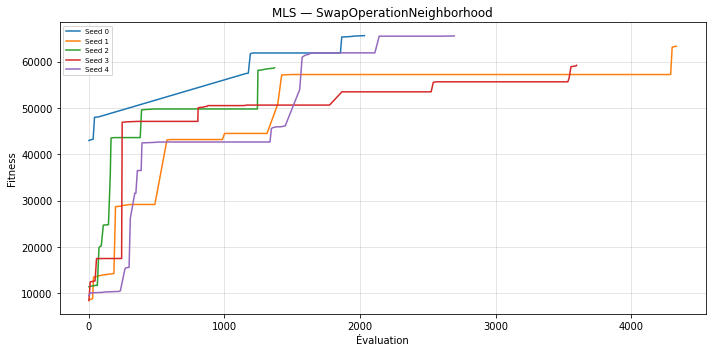

In [52]:
plot_mls(best_list_swap_op, index_best_list_swap_op, 'SwapOperationNeighborhood')

In [53]:
results_swap_op = stats_mls(best_c_swap_op, 'SwapOperationNeighborhood')
all_results['SwapOperationNeighborhood'] = results_swap_op


  SwapOperationNeighborhood
  Résultats : [65597.8767 63309.3369 58670.7781 59198.3088 65537.1871]
  Moyenne   : 62462.6975
  Std       : 3001.1171
  Meilleur  : 65597.8767
  Pire      : 58670.7781


## 2. MoveOneOperationNeighborhood

In [54]:
neighborhood_move_op = MoveOneOperationNeighborhood()

times_move_op, all_viewed_move_op, best_list_move_op, index_best_list_move_op, best_c_move_op = run_mls(
    neighborhood_move_op, 'MoveOneOperationNeighborhood'
)


>>> MLS — MoveOneOperationNeighborhood
  Seed 1/5 → fitness=65041.3334  (25.6s)
  Seed 2/5 → fitness=69931.7592  (20.1s)
  Seed 3/5 → fitness=65024.7394  (21.4s)
  Seed 4/5 → fitness=48884.9788  (23.3s)
  Seed 5/5 → fitness=50908.4003  (15.9s)


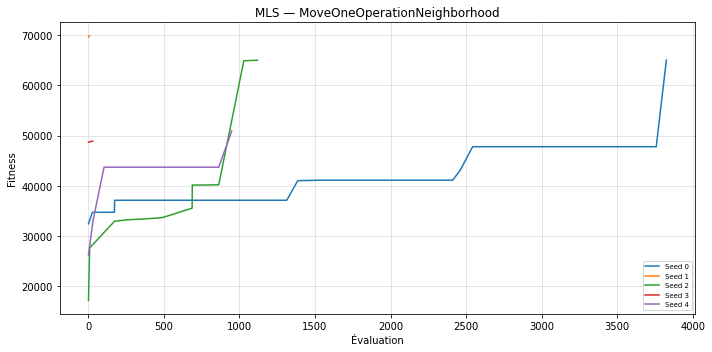

In [55]:
plot_mls(best_list_move_op, index_best_list_move_op, 'MoveOneOperationNeighborhood')

In [56]:
results_move_op = stats_mls(best_c_move_op, 'MoveOneOperationNeighborhood')
all_results['MoveOneOperationNeighborhood'] = results_move_op


  MoveOneOperationNeighborhood
  Résultats : [65041.3334 69931.7592 65024.7394 48884.9788 50908.4003]
  Moyenne   : 59958.2422
  Std       : 8432.0229
  Meilleur  : 69931.7592
  Pire      : 48884.9788


## 3. SwapFixedOperationsNeighborhood

In [57]:
neighborhood_swap_fixed = SwapFixedOperationsNeighborhood(k=10, n=10)

times_swap_fixed, all_viewed_swap_fixed, best_list_swap_fixed, index_best_list_swap_fixed, best_c_swap_fixed = run_mls(
    neighborhood_swap_fixed, 'SwapFixedOperationsNeighborhood'
)


>>> MLS — SwapFixedOperationsNeighborhood
  Seed 1/5 → fitness=63023.5081  (20.2s)
  Seed 2/5 → fitness=59818.3106  (23.3s)
  Seed 3/5 → fitness=55655.1447  (24.9s)
  Seed 4/5 → fitness=67604.0623  (19.4s)
  Seed 5/5 → fitness=65531.5781  (15.0s)


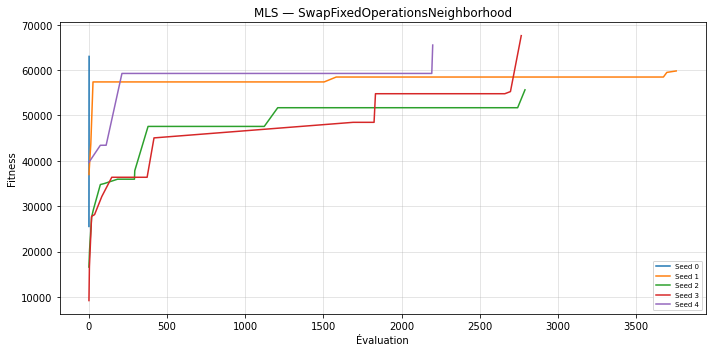

In [58]:
plot_mls(best_list_swap_fixed, index_best_list_swap_fixed, 'SwapFixedOperationsNeighborhood')

In [59]:
results_swap_fixed = stats_mls(best_c_swap_fixed, 'SwapFixedOperationsNeighborhood')
all_results['SwapFixedOperationsNeighborhood'] = results_swap_fixed


  SwapFixedOperationsNeighborhood
  Résultats : [63023.5081 59818.3106 55655.1447 67604.0623 65531.5781]
  Moyenne   : 62326.5208
  Std       : 4228.6879
  Meilleur  : 67604.0623
  Pire      : 55655.1447


## 7. ChangebaseWorkerNeighborhood

In [60]:
neighborhood_change_base = ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gen)

times_change_base, all_viewed_change_base, best_list_change_base, index_best_list_change_base, best_c_change_base = run_mls(
    neighborhood_change_base, 'ChangebaseWorkerNeighborhood'
)


>>> MLS — ChangebaseWorkerNeighborhood
  Seed 1/5 → fitness=73756.5356  (24.8s)
  Seed 2/5 → fitness=70660.3540  (24.2s)
  Seed 3/5 → fitness=79224.3430  (26.7s)
  Seed 4/5 → fitness=73744.6751  (28.2s)
  Seed 5/5 → fitness=72826.8982  (26.6s)


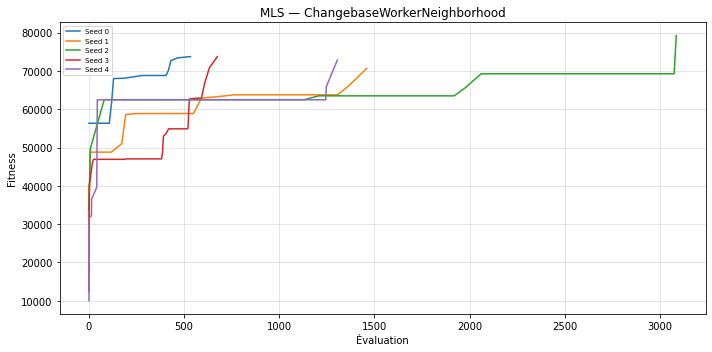

In [61]:
plot_mls(best_list_change_base, index_best_list_change_base, 'ChangebaseWorkerNeighborhood')

In [62]:
results_change_base = stats_mls(best_c_change_base, 'ChangebaseWorkerNeighborhood')
all_results['ChangebaseWorkerNeighborhood'] = results_change_base


  ChangebaseWorkerNeighborhood
  Résultats : [73756.5356 70660.354  79224.343  73744.6751 72826.8982]
  Moyenne   : 74042.5612
  Std       : 2826.2544
  Meilleur  : 79224.3430
  Pire      : 70660.3540


## 10. multipleNeighborhood_alternating

In [63]:
neighborhood_alternating = multipleNeighborhood_alternating(
    n1=SwapOperationNeighborhood(n=10),
    n2=ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gen)
)

times_alternating, all_viewed_alternating, best_list_alternating, index_best_list_alternating, best_c_alternating = run_mls(
    neighborhood_alternating, 'multipleNeighborhood_alternating'
)


>>> MLS — multipleNeighborhood_alternating
  Seed 1/5 → fitness=75849.6350  (17.6s)
  Seed 2/5 → fitness=70593.9379  (19.0s)
  Seed 3/5 → fitness=79384.3460  (18.5s)
  Seed 4/5 → fitness=68699.0727  (18.0s)
  Seed 5/5 → fitness=78929.7159  (17.9s)


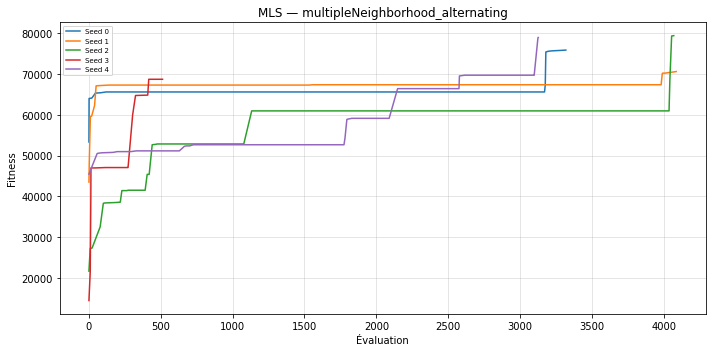

In [64]:
plot_mls(best_list_alternating, index_best_list_alternating, 'multipleNeighborhood_alternating')

In [65]:
results_alternating = stats_mls(best_c_alternating, 'multipleNeighborhood_alternating')
all_results['multipleNeighborhood_alternating'] = results_alternating


  multipleNeighborhood_alternating
  Résultats : [75849.635  70593.9379 79384.346  68699.0727 78929.7159]
  Moyenne   : 74691.3415
  Std       : 4336.4906
  Meilleur  : 79384.3460
  Pire      : 68699.0727


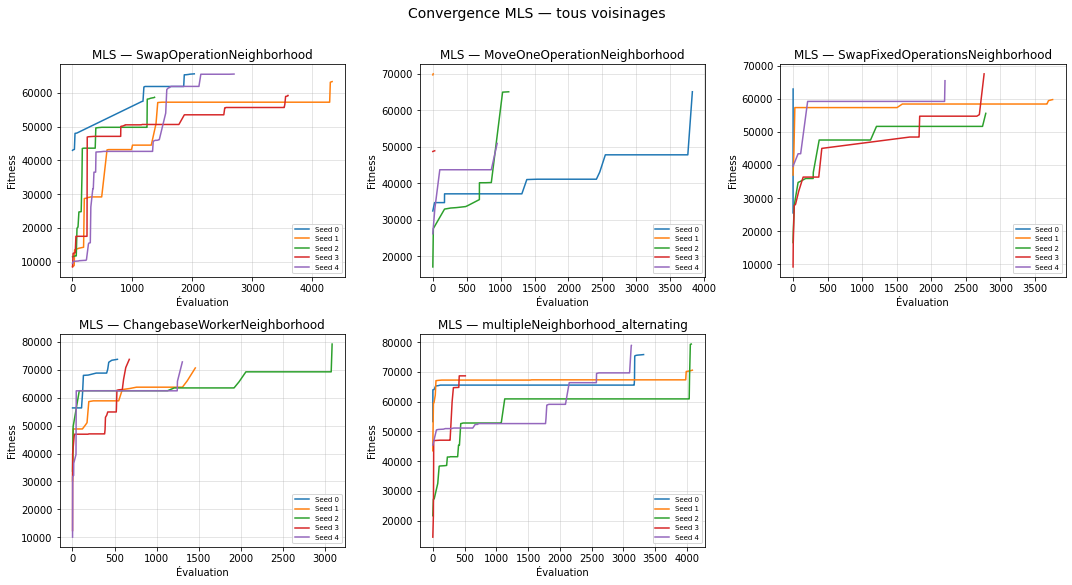

In [66]:
n_neigh = len(all_results)
ncols   = 3
nrows   = (n_neigh + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

neighborhoods_data = [
    ('SwapOperationNeighborhood', best_list_swap_op, index_best_list_swap_op),
    ('MoveOneOperationNeighborhood', best_list_move_op, index_best_list_move_op),
    ('SwapFixedOperationsNeighborhood', best_list_swap_fixed, index_best_list_swap_fixed),
    # ('MoveJobNeighborhood', best_list_move_job, index_best_list_move_job),
    # ('ShuffleOperationsNeighborhood', best_list_shuffle, index_best_list_shuffle),
    # ('MoveSecondWorkerNeighborhood', best_list_move_swac, index_best_list_move_swac),
    ('ChangebaseWorkerNeighborhood', best_list_change_base, index_best_list_change_base),
    # ('PrioritizeUnfinishedJobNeighborhood', best_list_prioritize, index_best_list_prioritize),
    # ('RandomRestartNeighborhood', best_list_random_restart, index_best_list_random_restart),
    ('multipleNeighborhood_alternating', best_list_alternating, index_best_list_alternating),
    # ('multipleNeighborhood_cumulative', best_list_cumulative, index_best_list_cumulative),
]

for i, (name, bl, idx_bl) in enumerate(neighborhoods_data):
    plot_mls(bl, idx_bl, name, ax=axes[i])

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Convergence MLS — tous voisinages', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

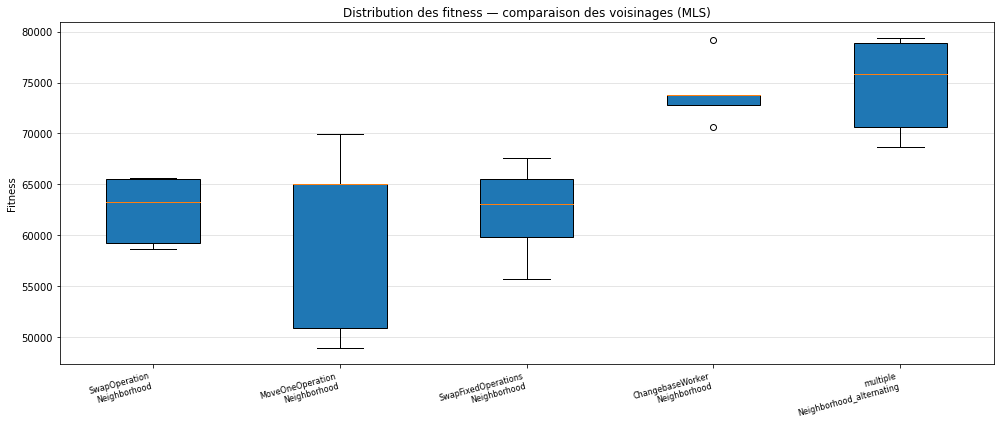

In [67]:
fig, ax = plt.subplots(figsize=(14, 6))
labels  = list(all_results.keys())
data    = [all_results[k] for k in labels]
bp = ax.boxplot(data, patch_artist=True, notch=False)
ax.set_xticklabels(
    [l.replace('Neighborhood', '\nNeighborhood') for l in labels],
    fontsize=8, rotation=15, ha='right'
)
ax.set_ylabel('Fitness')
ax.set_title('Distribution des fitness — comparaison des voisinages (MLS)')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

In [68]:
df_stats = pd.DataFrame({
    name: {
        'mean':  float(np.mean(v)),
        'std':   float(np.std(v)),
        'best':  float(np.max(v)),
        'worst': float(np.min(v)),
    }
    for name, v in all_results.items()
}).T.round(4)

df_stats = df_stats.sort_values('mean', ascending=False)
df_stats

,mean,std,best,worst
multipleNeighborhood_alternating,74691.3415,4336.4906,79384.3460,68699.0727
ChangebaseWorkerNeighborhood,74042.5612,2826.2544,79224.3430,70660.3540
SwapOperationNeighborhood,62462.6975,3001.1171,65597.8767,58670.7781
SwapFixedOperationsNeighborhood,62326.5208,4228.6879,67604.0623,55655.1447
MoveOneOperationNeighborhood,59958.2422,8432.0229,69931.7592,48884.9788
